In [18]:
from typing import Annotated
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from rich import print
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI

In [6]:
# Create a state class that includes a list of messages 
class State(TypedDict):
    message: Annotated[list, add_messages]

In [7]:
llm=ChatMistralAI(model_name="mistral-small-latest")

In [8]:
# Node Functionality 
def chatbot(state:State):
    return {"message":[llm.invoke(state['message'])]}

In [24]:
# Building Graph
graph_builder=StateGraph(State)
# Adding Nodes
graph_builder.add_node("llmchatbot",chatbot)
#Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
# Compiled Graph builder (Compile the graph builder)
graph=graph_builder.compile()

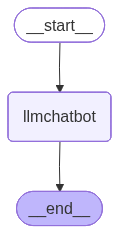

In [ ]:
# Compile and Visualize the Graph (Or can use IPython Library)
graph.compile()

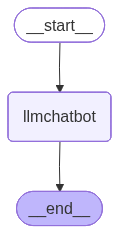

In [25]:
from IPython.display import display , Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

In [ ]:
# Invoke the Compiled State Graph
response=graph.invoke({'message':"Tell me a joke"})

In [19]:
print(response)

{
    'message': [
        HumanMessage(
            content='Tell me a joke',
            additional_kwargs={},
            response_metadata={},
            id='a25e0257-1bc1-4764-9530-fb97400d047f'
        ),
        AIMessage(
            content="Here's one for you:\n\n**Why don’t skeletons fight each other?**\n*Because they don’t have the
guts!* 😄\n\nWant another? Let me know!",
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'prompt_tokens': 19,
                    'total_tokens': 58,
                    'completion_tokens': 39,
                    'prompt_tokens_details': {'cached_tokens': 0}
                },
                'model_name': 'mistral-small-latest',
                'model': 'mistral-small-latest',
                'finish_reason': 'stop',
                'model_provider': 'mistralai'
            },
            id='lc_run--019e00a8-829d-76c3-b689-2f71512e89c1-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 19, 'output_tokens': 39, 'total_tokens': 58}
        )
    ]
}

In [22]:
print(response['message'][-1])

AIMessage(
    content="Here's one for you:\n\n**Why don’t skeletons fight each other?**\n*Because they don’t have the guts!* 
😄\n\nWant another? Let me know!",
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 19,
            'total_tokens': 58,
            'completion_tokens': 39,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-latest',
        'model': 'mistral-small-latest',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019e00a8-829d-76c3-b689-2f71512e89c1-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 19, 'output_tokens': 39, 'total_tokens': 58}
)

In [23]:
print(response['message'][-1].content)

Here's one for you:

**Why don’t skeletons fight each other?**
*Because they don’t have the guts!* 😄

Want another? Let me know!